In [1]:
using BenchmarkTools

using FastChebInterp
using JLD2
using QuadGK

In [2]:
# The domains of L₁(A, B, C) and L₂(A, B, C) are split in three parts along the dimension C, where C = log₁₀H.
# The split was adjusted to make the number of coefficients in each domain approximately the same.

# Domains lower and upper bounds
L₁_lb = [
    [0.0, 0.0, -2.0],
    [0.0, 0.0, 0.15],
    [0.0, 0.0, 0.95],
]

L₁_ub = [
    [0.5, 1.0, 0.15],
    [0.5, 1.0, 0.95],
    [0.5, 1.0, 2.0],
]

L₂_lb = [
    [0.0, 0.0, -2.0],
    [0.0, 0.0, 0.11],
    [0.0, 0.0, 0.84],
]

L₂_ub = [
    [0.5, 1.0, 0.11],
    [0.5, 1.0, 0.84],
    [0.5, 1.0, 2.0],
]

# Polynomial order
L₁_n = [
    (14, 18, 40),
    (16, 19, 40),
    (16, 20, 40),
]

L₂_n = [
    (11, 18, 38),
    (13, 21, 38),
    (13, 21, 38),
];

In [19]:
# function L₁(x::AbstractVector{<:Real})
#     A, B, C = x
#     H = 10.0^C  # C = log₁₀H
    
#     f(u) = (u + H) / (u - H - (u + H)*exp(-2u))
#     g(u) = exp(-u*(2+B)) + exp(-u*(2-B))
#     h(u) = cos(u*A)
#     p(u) = (f(u) * g(u) * h(u) + exp(-u)) / u
    
#     path = (0.0, H+im, H+1.0, Inf)
#     y = 0.0
#     count = 0
    
#     for i in 1:length(path)-1
#         y, _, c = quadgk_count(p, path[i], path[i+1]; rtol=eps(), atol=eps(), maxevals=1e4, order=14)
#         count += c
#     end

#     println("x = [", A, ", ", B, ", ", C, "]  # count = $count")
    
#     return real(y)
# end


function L₂(x::AbstractVector{<:Real})
    A, B, C = x
    H = 10.0^C  # C = log₁₀H

    f(u) = (u + H) / (u - H - (u + H)*exp(-2u))
    g(u) = (u + H)^2 / ((u - H)^2 - (u^2 - H^2)*exp(-2u))
    p(u) = exp(-u*(2+B))
    q(u) = exp(-u*(4-B))
    r(u) = cos(u*A)
    
    h(u) = (f(u)*p(u) + g(u)*q(u)) * r(u) / u
    
    path = (0.0, H+im, H+1.0, Inf)
    y = 0.0
    
    for i in 1:length(path)-1
        y += quadgk(h, path[i], path[i+1]; rtol=eps(), atol=eps(), maxevals=1e4, order=15)[1]
    end
    
    return real(y)
end


function generate_coefficients(L, lb, ub, n; tol=eps())
    x = chebpoints(n, lb, ub)
    c = chebinterp(L.(x), lb, ub; tol=tol)
    return c.coefs
end;


function L₁(x::AbstractVector{<:Real})
    A, B, C = x
    H = 10.0^C  # C = log₁₀H
    
    f(u) = (u + H) / (u - H - (u + H)*exp(-2u))
    g(u) = exp(-u*(2+B)) + exp(-u*(2-B))
    h(u) = cos(u*A)
    p(u) = (f(u) * g(u) * h(u) + exp(-u)) / u
    
    path = (0.0, H+im, H+1.0, Inf)
    y = 0.0
    
    for i in 1:length(path)-1
        y += quadgk(p, path[i], path[i+1]; rtol=eps(), atol=eps(), maxevals=1e4, order=35)[1]
    end
    
    return real(y)
end;

In [20]:
# order = 5  -> 825, 671, 561
# order = 7  -> 375, 255, 315
# order = 10 -> 399, 1407, 231
# order = 12 -> 225, 175, 225
# order = 15 -> 217, 4841363, 279
# order = 20 -> 205, 287, 287
# order = 21 -> 215, 301, 301
# order = 22 -> 10000035, 10000035, 315
# order = 25 -> 255, 561, 357

# x = [0.45225424859373686, 1.0, 0.1499999999999999]  # count = 10000635, order = 7
# x = [0.45225424859373686, 1.0, 0.1499999999999999]  # count = 765, order = 8
# x = [0.45225424859373686, 1.0, 0.1499999999999999]  # count = 1209, order = 6
# x = [0.45225424859373686, 1.0, 0.1499999999999999]  # count = 10001123, order = 5
# x = [0.45225424859373686, 1.0, 0.1499999999999999]  # count = 779, order = 9
# x = [0.45225424859373686, 1.0, 0.1499999999999999]  # count = 10000389, order = 10
# x = [0.45225424859373686, 1.0, 0.1499999999999999]  # count = 10000423, order = 11
# x = [0.45225424859373686, 1.0, 0.1499999999999999]  # count = 525, order = 12
# x = [0.45225424859373686, 1.0, 0.1499999999999999]  # count = 459, order = 13  # sweet spot at the moment
# x = [0.45225424859373686, 1.0, 0.1499999999999999]  # count = 435, order = 14
# x = [0.45225424859373686, 1.0, 0.1499999999999999]  # count = 10000383, order = 15

x = [0.0, 0.0, -2.0]
println(L₁(x))
println(L₂(x))

-1.1422876154832495
-8.333577396646369


In [22]:
# L₁, d=1, order = 7  -> 2.873 s (291854 allocations: 137.99 MiB)
# L₁, d=1, order = 8  -> 4.488 s (306670 allocations: 213.16 MiB)
# L₁, d=1, order = 9  -> 3.794 s (294260 allocations: 97.68 MiB)
# L₁, d=1, order = 10 -> 3.408 s (288061 allocations: 89.59 MiB)
# L₁, d=1, order = 11 -> 1.676 s (271644 allocations: 51.65 MiB)
# L₁, d=1, order = 12 -> 1.677 s (271700 allocations: 51.74 MiB)
# L₁, d=1, order = 13 -> 1.544 s (266941 allocations: 43.79 MiB)
# L₁, d=1, order = 14 -> 3.961 s (284235 allocations: 91.95 MiB)
# L₁, d=1, order = 15 -> 11.339 s (317312 allocations: 225.01 MiB)
# L₁, d=1, order = 16 -> 1.371 s (261337 allocations: 37.11 MiB)
# L₁, d=1, order = 17 -> 6.822 s (293756 allocations: 140.88 MiB)
# L₁, d=1, order = 18 -> 1.289 s (253924 allocations: 34.25 MiB)
# L₁, d=1, order = 19 -> 20.376 s (337114 allocations: 357.06 MiB)
# L₁, d=1, order = 20 -> 1.080 s (246482 allocations: 27.15 MiB)
# L₁, d=1, order = 21 -> 1.120 s (244752 allocations: 26.42 MiB)
# L₁, d=1, order = 22 -> 21.279 s (340749 allocations: 373.03 MiB)
# L₁, d=1, order = 23 -> 10.282 s (288587 allocations: 173.79 MiB)
# L₁, d=1, order = 24 -> 1.932 s (238611 allocations: 39.64 MiB)
# L₁, d=1, order = 25 -> 1.058 s (226654 allocations: 23.88 MiB)
# L₁, d=1, order = 26 -> 1.070 s (224798 allocations: 22.39 MiB)  # Best = 26
# L₁, d=1, order = 27 -> 1.340 s (230407 allocations: 27.87 MiB)
# L₁, d=1, order = 28 -> 2.415 s (238608 allocations: 43.26 MiB)
# L₁, d=1, order = 29 -> 1.279 s (229668 allocations: 25.86 MiB)
# L₁, d=1, order = 30 -> 1.168 s (220736 allocations: 23.64 MiB)  # 2nd best = 30
# L₁, d=1, order = 31 -> 1.731 s (227443 allocations: 29.81 MiB)
# L₁, d=1, order = 32 -> 1.369 s (212469 allocations: 23.88 MiB)  # 3rd best = 32
# L₁, d=1, order = 33 -> 1.690 s (231151 allocations: 26.79 MiB)
# L₁, d=1, order = 34 -> 1.453 s (229296 allocations: 23.98 MiB)  # 4th best = 34
# L₁, d=1, order = 35 -> 17.474 s (287138 allocations: 270.60 MiB)

# L₁, d=2, order = 6  -> 8.548 s (383558 allocations: 441.05 MiB)
# L₁, d=2, order = 20 -> 1.884 s (274676 allocations: 40.81 MiB)
# L₁, d=2, order = 25 -> 1.496 s (253084 allocations: 33.12 MiB)
# L₁, d=2, order = 26 -> 1.413 s (251713 allocations: 31.48 MiB)
# L₁, d=2, order = 27 -> 1.394 s (249138 allocations: 31.60 MiB)
# L₁, d=2, order = 30 -> 1.988 s (248579 allocations: 30.17 MiB)  # 3rd best = 30
# L₁, d=2, order = 31 -> 1.904 s (246121 allocations: 31.65 MiB)
# L₁, d=2, order = 32 -> 1.799 s (247077 allocations: 31.72 MiB)
# L₁, d=2, order = 33 -> 2.150 s (248975 allocations: 29.73 MiB)  # 2nd best = 33
# L₁, d=2, order = 34 -> 1.704 s (242729 allocations: 29.45 MiB)  # Best = 34
# L₁, d=2, order = 35 -> 4.909 s (262683 allocations: 89.19 MiB)

# L₁, d=3, order = 25 -> 1.339 s (244783 allocations: 29.64 MiB)
# L₁, d=3, order = 26 -> 1.310 s (244221 allocations: 28.57 MiB)
# L₁, d=3, order = 27 -> 1.294 s (240643 allocations: 27.98 MiB)
# L₁, d=3, order = 30 -> 1.823 s (239952 allocations: 27.81 MiB)
# L₁, d=3, order = 31 -> 1.628 s (237233 allocations: 26.81 MiB)
# L₁, d=3, order = 32 -> 1.753 s (237726 allocations: 26.52 MiB)
# L₁, d=3, order = 33 -> 1.565 s (235476 allocations: 24.33 MiB)  # 2nd best = 33
# L₁, d=3, order = 34 -> 1.386 s (227132 allocations: 22.10 MiB)  # Best = 34
# L₁, d=3, order = 35 -> 1.909 s (232190 allocations: 28.96 MiB)

#################################################################

# L₂, d=1, order = 7  -> 1.982 s (227006 allocations: 88.71 MiB)
# L₂, d=1, order = 15 -> 8.441 s (218209 allocations: 124.13 MiB)
# L₂, d=1, order = 20 -> 910.381 ms (192309 allocations: 19.66 MiB)
# L₂, d=1, order = 24 -> 1.260 s (184530 allocations: 21.78 MiB)
# L₂, d=1, order = 25 -> 681.183 ms (174912 allocations: 15.32 MiB)
# L₂, d=1, order = 26 -> 692.018 ms (171822 allocations: 14.89 MiB)
# L₂, d=1, order = 27 -> 863.282 ms (177677 allocations: 17.38 MiB)
# L₂, d=1, order = 30 -> 822.860 ms (161718 allocations: 14.56 MiB)
# L₂, d=1, order = 31 -> 1.056 s (169364 allocations: 16.59 MiB)
# L₂, d=1, order = 32 -> 763.015 ms (156662 allocations: 12.94 MiB)  # Best = 32
# L₂, d=1, order = 33 -> 1.066 s (165669 allocations: 15.96 MiB)
# L₂, d=1, order = 34 -> 1.030 s (164305 allocations: 15.61 MiB)
# L₂, d=1, order = 35 -> 14.068 s (196197 allocations: 166.58 MiB)

# L₂, d=2, order = 10 -> 1.169 s (262404 allocations: 33.23 MiB)
# L₂, d=2, order = 15 -> 1.396 s (243958 allocations: 29.93 MiB)
# L₂, d=2, order = 20 -> 652.151 ms (222423 allocations: 16.40 MiB)
# L₂, d=2, order = 24 -> 608.036 ms (189714 allocations: 12.68 MiB)
# L₂, d=2, order = 25 -> 509.357 ms (187045 allocations: 11.26 MiB)
# L₂, d=2, order = 26 -> 536.701 ms (184214 allocations: 12.32 MiB)
# L₂, d=2, order = 27 -> 550.099 ms (184986 allocations: 11.59 MiB)
# L₂, d=2, order = 30 -> 555.585 ms (177164 allocations: 10.64 MiB)
# L₂, d=2, order = 31 -> 709.856 ms (174532 allocations: 11.58 MiB)
# L₂, d=2, order = 32 -> 609.871 ms (175209 allocations: 10.73 MiB)
# L₂, d=2, order = 33 -> 743.172 ms (172981 allocations: 10.43 MiB)
# L₂, d=2, order = 34 -> 674.801 ms (172299 allocations: 10.43 MiB)  # Best = 34
# L₂, d=2, order = 35 -> 1.656 s (174106 allocations: 21.10 MiB)

# L₂, d=3, order = 20 -> 840.424 ms (188237 allocations: 17.20 MiB)
# L₂, d=3, order = 24 -> 867.736 ms (187453 allocations: 17.04 MiB)
# L₂, d=3, order = 25 -> 825.438 ms (186810 allocations: 16.32 MiB)
# L₂, d=3, order = 26 -> 871.998 ms (185492 allocations: 15.99 MiB)
# L₂, d=3, order = 27 -> 940.882 ms (185602 allocations: 16.03 MiB)
# L₂, d=3, order = 30 -> 1.207 s (184838 allocations: 15.60 MiB)
# L₂, d=3, order = 31 -> 1.131 s (183570 allocations: 15.31 MiB)
# L₂, d=3, order = 32 -> 962.690 ms (180677 allocations: 14.15 MiB)  # Best = 32
# L₂, d=3, order = 33 -> 1.120 s (183468 allocations: 15.71 MiB)
# L₂, d=3, order = 34 -> 1.038 s (182206 allocations: 14.67 MiB)
# L₂, d=3, order = 35 -> 1.187 s (180574 allocations: 15.33 MiB)

####################################################################

# L₁ order = 25 - 34. Best order = 32.
# L₂ order = 25 - 34. Best order = 32.

@btime begin
    i = 3
    coefs = generate_coefficients(L₁, L₁_lb[i], L₁_ub[i], L₁_n[i])
    # coefs = generate_coefficients(L₂, L₂_lb[i], L₂_ub[i], L₂_n[i])
end;

  1.909 s (232190 allocations: 28.96 MiB)


In [6]:
coefs.size

LoadError: UndefVarError: `coefs` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [6]:
L₁_coefficients = [generate_coefficients(L₁, L₁_lb[i], L₁_ub[i], L₁_n[i]) for i in 1:3]

LoadError: InterruptException:

In [4]:
np, nq, nr = 14, 18, 40

lb, ub = [A1, B1, logH1], [A2, B2, logH2]
x = chebpoints((np, nq, nr), lb, ub)
c = chebinterp(L₁.(x), lb, ub, tol=eps())
coefs = c.coefs

println("coefs size = $(coefs.size)")
println("cA_end = ", maximum(abs.(coefs[end, :, :])))
println("cB_end = ", maximum(abs.(coefs[:, end, :])))
println("clogH_end = ", maximum(abs.(coefs[:, :, end])))

@save "coefs/l1coefs/coefs$domain.jld2" coefs

coefs size = (15, 19, 41)
cA_end = 5.639455803156718e-15
cB_end = 1.3531934198614898e-15
clogH_end = 6.0903663065151445e-16


In [5]:
using CairoMakie
using Statistics

In [6]:
coefs_A = [maximum(abs.(coefs[i, :, :])) for i in 1:size(coefs, 1)]
coefs_B = [maximum(abs.(coefs[:, j, :])) for j in 1:size(coefs, 2)]
coefs_logH = [maximum(abs.(coefs[:, :, k])) for k in 1:size(coefs, 3)];

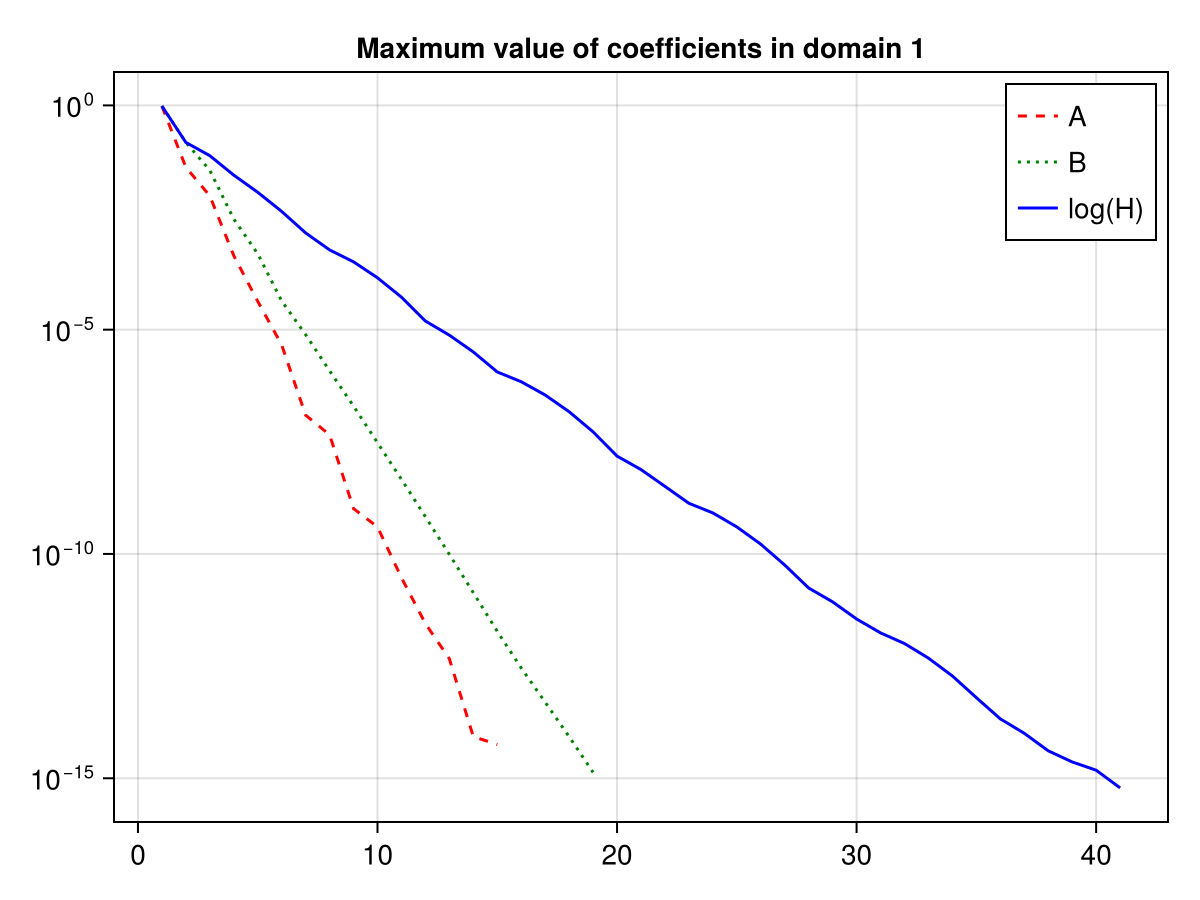

In [7]:
fig = Figure()
ax = Axis(fig[1, 1], yscale=log10, title="Maximum value of coefficients in domain 1")
lines!(ax, 1:size(coefs, 1), coefs_A, color=:red, linestyle=:dash, label="A")
lines!(ax, 1:size(coefs, 2), coefs_B, color=:green, linestyle=:dot, label="B")
lines!(ax, 1:size(coefs, 3), coefs_logH, color=:blue, linestyle=:solid, label="log(H)")
axislegend(ax)
fig